In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import matplotlib.dates as mdates

%matplotlib inline

In [103]:
with open("wpe-ews.json") as handle:
    json_data = json.load(handle)
builds = json_data['builds']
builds

[{'builderid': 34,
  'buildid': 801648,
  'buildrequestid': 775262,
  'complete': False,
  'complete_at': None,
  'masterid': 1,
  'number': 22322,
  'properties': {},
  'results': None,
  'started_at': 1698268359,
  'state_string': 'building',
  'workerid': 77},
 {'builderid': 34,
  'buildid': 801601,
  'buildrequestid': 775161,
  'complete': False,
  'complete_at': None,
  'masterid': 1,
  'number': 22321,
  'properties': {},
  'results': None,
  'started_at': 1698267533,
  'state_string': 'building',
  'workerid': 138},
 {'builderid': 34,
  'buildid': 801518,
  'buildrequestid': 775082,
  'complete': False,
  'complete_at': None,
  'masterid': 1,
  'number': 22320,
  'properties': {},
  'results': None,
  'started_at': 1698266049,
  'state_string': 'building',
  'workerid': 66},
 {'builderid': 34,
  'buildid': 801517,
  'buildrequestid': 775014,
  'complete': True,
  'complete_at': 1698266049,
  'masterid': 1,
  'number': 22319,
  'properties': {},
  'results': 3,
  'started_at': 16

In [33]:
keys = ['buildid', 'complete', 'complete_at', 'results', 'started_at', 'state_string', 'workerid']

In [119]:
df = pd.DataFrame([{key: build[key] for key in keys} for build in builds])
df

,buildid,complete,complete_at,results,started_at,state_string,workerid
0,801648,False,NaN,NaN,1698268359,building,77
1,801601,False,NaN,NaN,1698267533,building,138
2,801518,False,NaN,NaN,1698266049,building,66
3,801517,True,1.698266e+09,3.0,1698266048,Pull request 19545 is already closed,66
4,801449,False,NaN,NaN,1698265661,building,113
...,...,...,...,...,...,...,...
22317,316,True,1.679441e+09,0.0,1679436121,build successful 23 flakes 117 failures 5 flak...,113
22318,269,True,1.679441e+09,0.0,1679435466,build successful 22 flakes 121 failures 6 flak...,51
22319,230,True,1.679440e+09,0.0,1679435009,build successful 14 flakes 117 failures 2 flak...,41
22320,200,True,1.679435e+09,3.0,1679434768,Hash 2ff5da6e on PR 11772 is outdated,51


array([ 77, 138,  66, 113,  51, 112,  41,  50])

In [145]:
df['obsolete'] = df['state_string'].str.endswith("is already closed")

df['skipped'] = df['results'] == 3.0
df['failed'] = df['results'] == 2.0
df['exception'] = df['results'] == 4.0
df['retry'] = df['results'] == 5.0
df['cancelled'] = df['results'] == 6.0
df['success'] = df['results'] == 0.0

df['git_issue'] = df['state_string'].str.contains("Git issue")
df['duration'] = pd.to_timedelta(df['complete_at'] - df['started_at'], unit='s').dt.total_seconds()
df['started_date'] = pd.to_datetime(df['started_at'], unit='s')
df

,buildid,complete,complete_at,results,started_at,state_string,workerid,obsolete,skipped,failed,exception,retry,cancelled,success,git_issue,duration,started_date
0,801648,False,NaN,NaN,1698268359,building,77,False,False,False,False,False,False,False,False,NaN,2023-10-25 21:12:39
1,801601,False,NaN,NaN,1698267533,building,138,False,False,False,False,False,False,False,False,NaN,2023-10-25 20:58:53
2,801518,False,NaN,NaN,1698266049,building,66,False,False,False,False,False,False,False,False,NaN,2023-10-25 20:34:09
3,801517,True,1.698266e+09,3.0,1698266048,Pull request 19545 is already closed,66,True,True,False,False,False,False,False,False,1.0,2023-10-25 20:34:08
4,801449,False,NaN,NaN,1698265661,building,113,False,False,False,False,False,False,False,False,NaN,2023-10-25 20:27:41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22317,316,True,1.679441e+09,0.0,1679436121,build successful 23 flakes 117 failures 5 flak...,113,False,False,False,False,False,False,True,False,4945.0,2023-03-21 22:02:01
22318,269,True,1.679441e+09,0.0,1679435466,build successful 22 flakes 121 failures 6 flak...,51,False,False,False,False,False,False,True,False,5171.0,2023-03-21 21:51:06
22319,230,True,1.679440e+09,0.0,1679435009,build successful 14 flakes 117 failures 2 flak...,41,False,False,False,False,False,False,True,False,4996.0,2023-03-21 21:43:29
22320,200,True,1.679435e+09,3.0,1679434768,Hash 2ff5da6e on PR 11772 is outdated,51,False,True,False,False,False,False,False,False,2.0,2023-03-21 21:39:28


In [129]:
obsoletes = df[['success', 'skipped', 'failed', 'exception', 'retry', 'started_date']]
obsoletes.set_index('started_date', inplace=True)
obsolete_avg = obsoletes.resample('D').mean()
obsolete_avg

,success,skipped,failed,exception,retry
started_date,,,,,
2023-03-21,0.500000,0.409091,0.090909,0.00000,0.000000
2023-03-22,0.250923,0.158672,0.040590,0.00738,0.538745
2023-03-23,0.202658,0.209302,0.039867,0.00000,0.501661
2023-03-24,0.607843,0.294118,0.098039,0.00000,0.000000
2023-03-25,0.582090,0.298507,0.119403,0.00000,0.000000
...,...,...,...,...,...
2023-10-21,0.529412,0.411765,0.058824,0.00000,0.000000
2023-10-22,0.526316,0.263158,0.078947,0.00000,0.131579
2023-10-23,0.657895,0.289474,0.052632,0.00000,0.000000


<Figure size 1000x600 with 0 Axes>

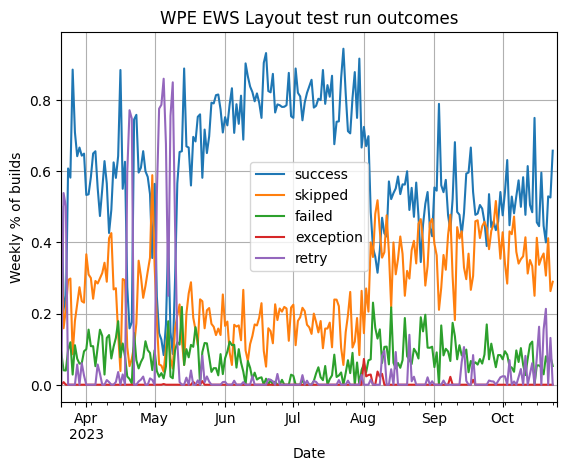

In [130]:
plt.figure(figsize=(10, 6))
obsolete_avg.plot()
plt.grid(True)
plt.xlabel('Date')
plt.ylabel('Weekly % of builds')
plt.title('WPE EWS Layout test run outcomes')
plt.show()

In [146]:
durations = df[(~df['skipped']) & (df['success'] | df['failed'])][['duration', 'started_date']]
durations.set_index('started_date', inplace=True)
durations

,duration
started_date,
2023-10-25 18:35:37,8595.0
2023-10-25 18:11:26,10873.0
2023-10-25 18:05:01,8947.0
2023-10-25 17:26:59,9530.0
2023-10-25 17:07:15,9917.0
...,...
2023-03-21 23:09:07,5435.0
2023-03-21 22:17:28,4884.0
2023-03-21 22:02:01,4945.0


AttributeError: module 'matplotlib.dates' has no attribute 'FuncFormatter'

<Figure size 1000x600 with 0 Axes>

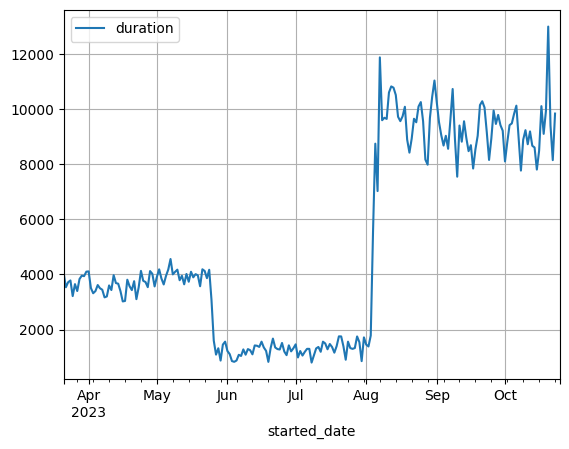

In [148]:
plt.figure(figsize=(10, 6))
durations.resample('D').mean().plot()
plt.grid(True)
ax = plt.gca()
ax.yaxis.set_major_formatter(mdates.FuncFormatter(lambda x, _: pd.Timedelta(seconds=x).strftime('%H:%M:%S')))
ax.yaxis.set_major_locator(mdates.MinuteLocator(interval=15)) 
plt.xlabel('Date')
plt.ylabel('Weekly % of builds')
plt.title('WPE EWS Layout test run duration')
plt.show()

duration   0 days 03:36:29.888888888
dtype: timedelta64[ns]